In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report, mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [50]:
df=pd.read_csv('water_potability.csv')

In [51]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [52]:
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [54]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3271    False
3272    False
3273    False
3274    False
3275    False
Length: 3276, dtype: bool

In [55]:
df.shape

(3276, 10)

In [56]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [57]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


# Imbalance Data

In [58]:

df['Potability']       # where 1 is perfect and 0 is not perfect

0       0
1       0
2       0
3       0
4       0
       ..
3271    1
3272    1
3273    1
3274    1
3275    1
Name: Potability, Length: 3276, dtype: int64

In [59]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [60]:
df.shape

(3276, 10)

In [61]:
print(round(len(df[df['Potability'] ==0] ) /len(df),2))
print(round(len(df[df['Potability'] ==1] ) /len(df),2))


0.61
0.39


## Missing data

In [62]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [63]:
df.isnull().mean()*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [64]:
for i in df.columns:
    if df[i].isnull().sum() >0:
        print(i)
    

ph
Sulfate
Trihalomethanes


------ph-----

 mean:7.080794504276835

median:7.036752103833548 



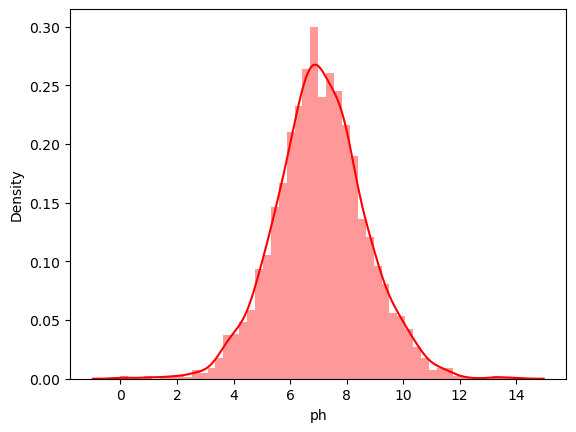

------Sulfate-----

 mean:333.7757766108135

median:333.073545745888 



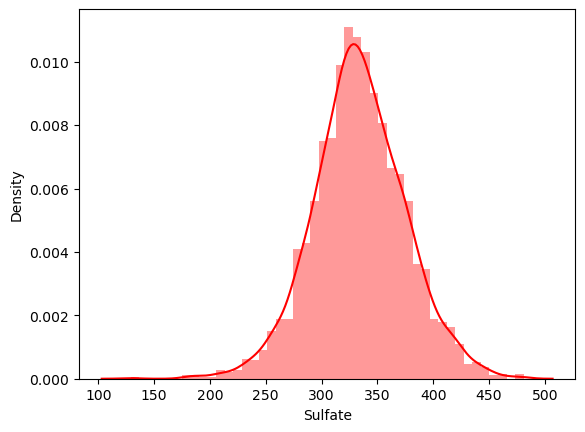

------Trihalomethanes-----

 mean:66.39629294676803

median:66.62248509808484 



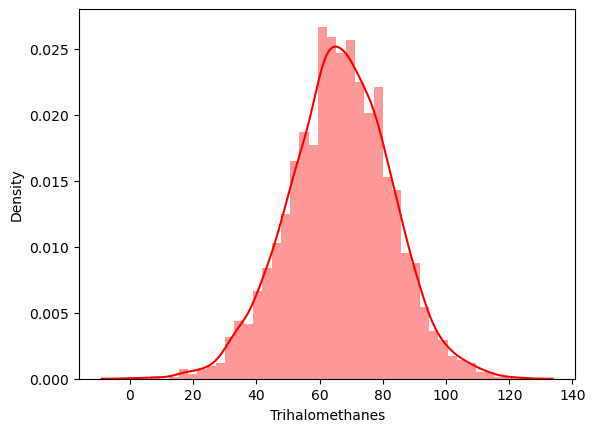

In [67]:
import matplotlib.pyplot as plt
for i in df.columns:
    if df[i].isnull().sum() >0:
        print(f'------{i}-----\n')
        print(f' mean:{df[i].mean()}\n')
        print(f'median:{df[i].median()} \n')
        sns.distplot(df[i],color='r')
        plt.show()
        

In [68]:
for i in  df.columns:
    if df[i].isnull().sum() >0:
        print(f' {i}---{df[i].mean()}')

 ph---7.080794504276835
 Sulfate---333.7757766108135
 Trihalomethanes---66.39629294676803


In [69]:
for i in df.columns:
    if df[i] .isnull().sum()>0:
        df[i].fillna(df[i].mean(),inplace=True)

In [70]:

df.isnull().sum()



ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

 # Duplicate value

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df[df.duplicated()]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability


In [73]:
df.drop_duplicates(keep ='first',inplace=True)
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


 # outliers
 

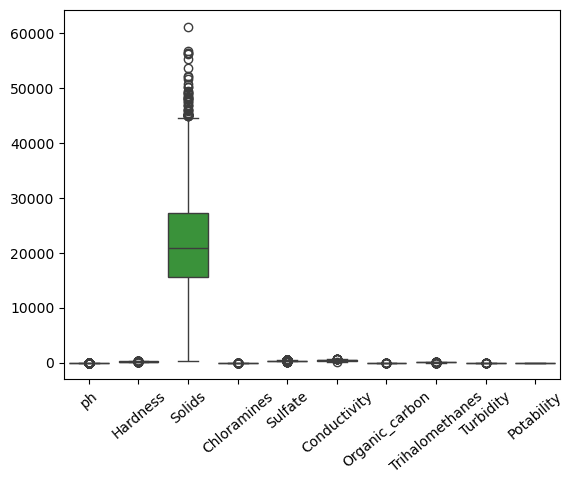

In [74]:
# using box plot
sns.boxplot(df)
plt.xticks(rotation=40)
plt.show()

---ph---



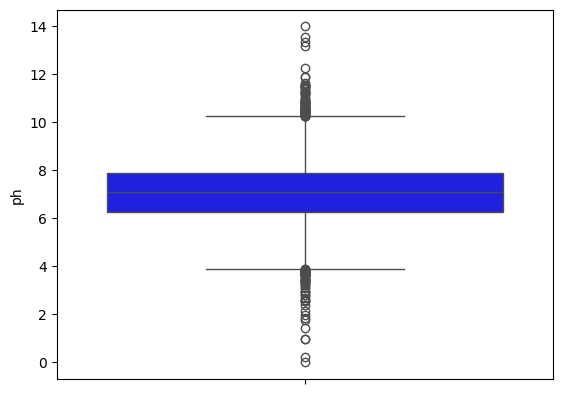

---Hardness---



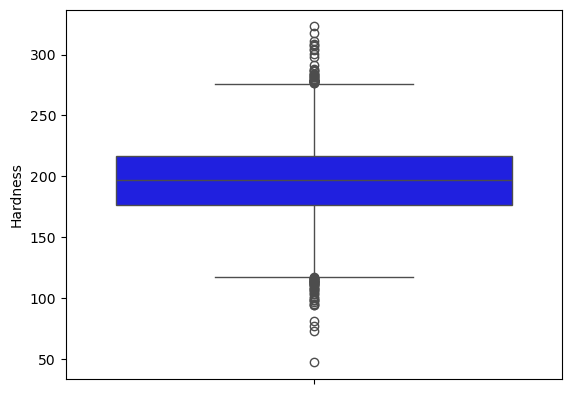

---Solids---



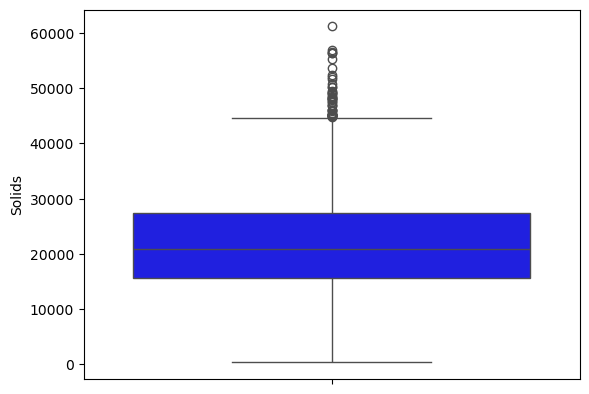

---Chloramines---



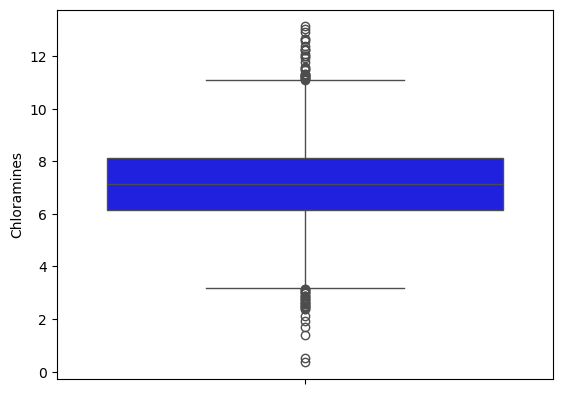

---Sulfate---



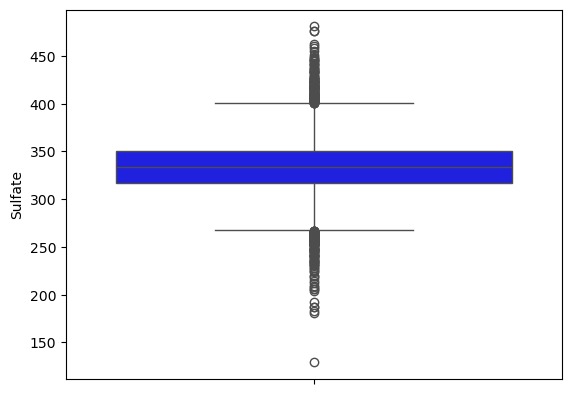

---Conductivity---



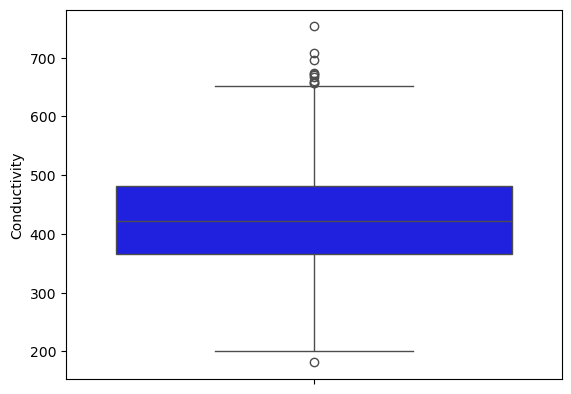

---Organic_carbon---



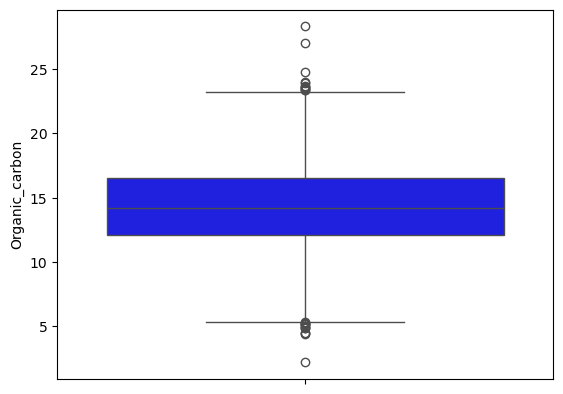

---Trihalomethanes---



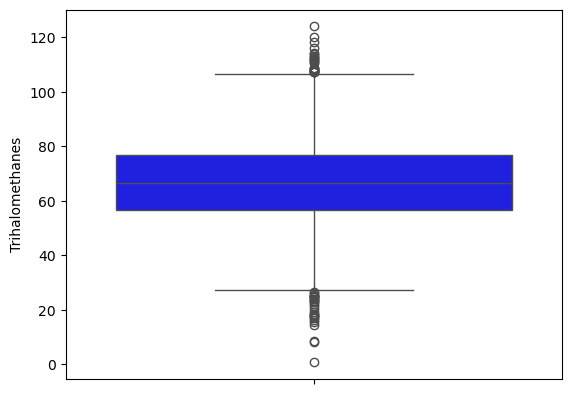

---Turbidity---



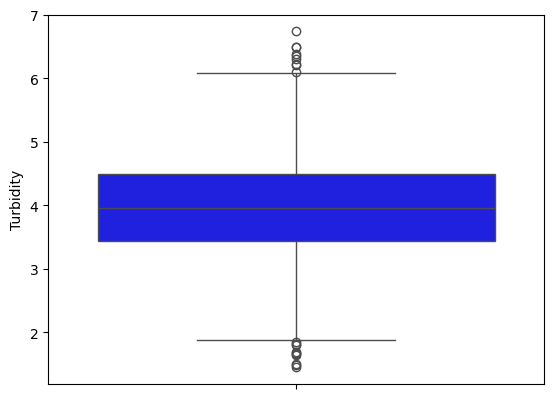

In [114]:
for i in df.columns:
    if i == 'Potability':
        pass
    else:
        print(f'---{i}---\n')
        sns.boxplot(df[i],color='b')
        plt.show()

## Using IQR ,removingboutliers

In [115]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)



In [116]:
IQR=Q3-Q1
IQR

ph                     1.592377
Hardness              39.816918
Solids             11666.071830
Chloramines            1.987466
Sulfate               33.291119
Conductivity         116.057890
Organic_carbon         4.491850
Trihalomethanes       20.018954
Turbidity              1.060609
Potability             1.000000
dtype: float64

In [117]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [118]:
lower_bound







ph                    3.889107
Hardness            117.125160
Solids            -1832.417449
Chloramines           3.146221
Sulfate             267.157960
Conductivity        191.647579
Organic_carbon        5.328026
Trihalomethanes      26.619225
Turbidity             1.848797
Potability           -1.500000
dtype: float64

In [119]:
upper_bound


ph                    10.258615
Hardness             276.392834
Solids             44831.869873
Chloramines           11.096086
Sulfate              400.322434
Conductivity         655.879140
Organic_carbon        23.295427
Trihalomethanes      106.695040
Turbidity              6.091233
Potability             2.500000
dtype: float64

In [120]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [121]:
df.shape

(3276, 10)

In [122]:
df[((df <lower_bound)|(df>upper_bound)).any(axis=1)]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0
18,8.975464,279.357167,19460.398131,6.204321,333.775777,431.443990,12.888759,63.821237,2.436086,0
26,3.445062,207.926260,33424.768678,8.782147,384.007006,441.785876,13.805902,30.284597,4.184397,0
32,10.433291,117.791230,22326.892046,8.161505,307.707509,412.986834,12.890709,65.733478,5.057311,0
...,...,...,...,...,...,...,...,...,...,...
3246,10.667364,173.381945,28912.202201,7.071294,276.634391,286.063394,17.685651,55.147364,4.135569,1
3249,10.808157,198.596751,29614.348790,5.782418,304.622061,383.269410,14.902820,47.896406,4.362542,1
3261,3.629922,244.187392,24856.633209,6.618071,366.967873,442.076337,13.302880,59.489294,4.754826,1
3269,11.491011,94.812545,37188.826022,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1


In [123]:
3276-610

2666

In [142]:
df=df[~((df <lower_bound)|(df>upper_bound)).any(axis=1)]
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
...,...,...,...,...,...,...,...,...,...,...
3270,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [143]:
df.shape

(2666, 10)

# Feature selection

In [147]:
df.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.131362,-0.087036,-0.062888,0.016894,0.001943,0.026160,0.009172,-0.043034,-0.005949
Hardness,0.131362,1.000000,-0.045552,-0.035832,-0.027939,-0.030415,0.012463,-0.007093,-0.022362,-0.000710
Solids,-0.087036,-0.045552,1.000000,-0.040392,-0.110090,0.007087,0.026793,-0.024550,0.022801,0.005600
Chloramines,-0.062888,-0.035832,-0.040392,1.000000,0.024502,-0.015277,-0.000684,0.016574,-0.005415,0.013195
Sulfate,0.016894,-0.027939,-0.110090,0.024502,1.000000,-0.005850,-0.007588,-0.022269,-0.017310,-0.003741
Conductivity,0.001943,-0.030415,0.007087,-0.015277,-0.005850,1.000000,0.006515,-0.001138,0.007674,-0.001886
Organic_carbon,0.026160,0.012463,0.026793,-0.000684,-0.007588,0.006515,1.000000,-0.000059,-0.016705,-0.027090
Trihalomethanes,0.009172,-0.007093,-0.024550,0.016574,-0.022269,-0.001138,-0.000059,1.000000,-0.024269,0.014351
Turbidity,-0.043034,-0.022362,0.022801,-0.005415,-0.017310,0.007674,-0.016705,-0.024269,1.000000,0.004761
Potability,-0.005949,-0.000710,0.005600,0.013195,-0.003741,-0.001886,-0.027090,0.014351,0.004761,1.000000


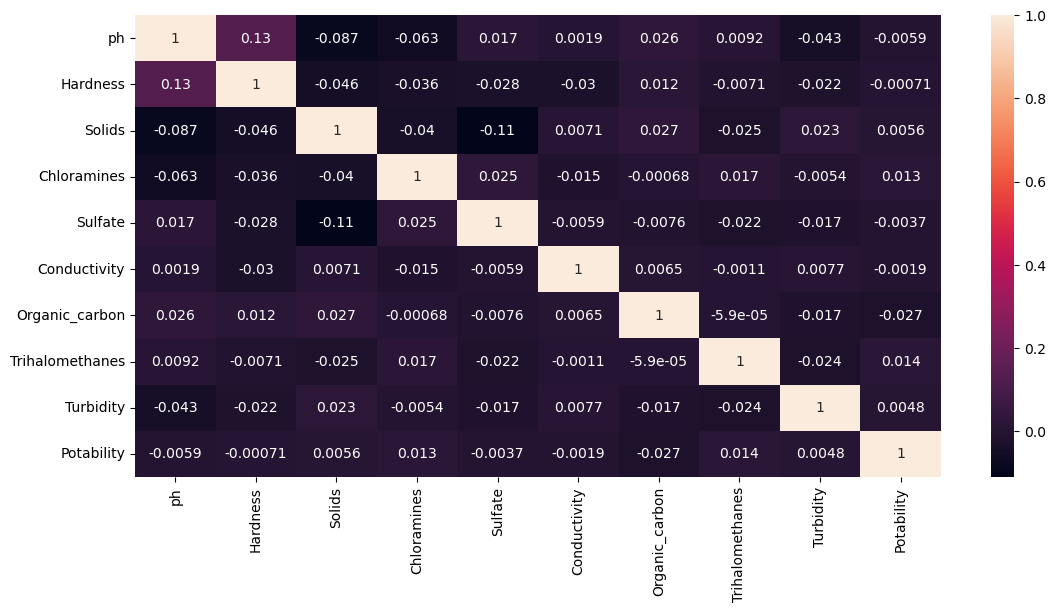

In [149]:
plt.figure(figsize=(13,6))
sns.heatmap(df.corr(),annot = True)
plt.show()

In [155]:
df.corr()['Potability']

ph                -0.005949
Hardness          -0.000710
Solids             0.005600
Chloramines        0.013195
Sulfate           -0.003741
Conductivity      -0.001886
Organic_carbon    -0.027090
Trihalomethanes    0.014351
Turbidity          0.004761
Potability         1.000000
Name: Potability, dtype: float64

 # Model building

In [ ]:
### 

In [156]:
 x=df.drop(columns=['Potability'] ,axis=1)

In [157]:
x

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708
...,...,...,...,...,...,...,...,...,...
3270,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658


In [159]:
y=df['Potability']

In [160]:
y

0       0
2       0
3       0
4       0
5       0
       ..
3270    1
3272    1
3273    1
3274    1
3275    1
Name: Potability, Length: 2666, dtype: int64

## data split into test and train data

In [161]:
 x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)


In [165]:
x_test.shape  ,  x_train.shape

((880, 9), (1786, 9))

In [166]:
y_test.shape  ,  y_train.shape

((880,), (1786,))

In [168]:
df.shape

(2666, 10)

In [192]:
x_test

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2553,8.037761,199.213971,40368.420627,7.307411,333.775777,293.833466,14.254682,68.763418,3.572519
2347,5.429335,183.439383,15265.407564,5.714731,394.001195,446.879149,17.581557,50.266951,3.081736
605,6.492639,172.863960,14625.561363,7.736570,349.404057,652.537592,10.212058,56.949724,4.667770
2323,5.277876,166.733007,18404.050689,4.777124,333.775777,347.219457,15.526043,63.008668,3.632607
912,8.274069,195.803331,18091.202615,7.422104,365.407222,369.198334,16.996330,66.396293,2.575423
...,...,...,...,...,...,...,...,...,...
3192,5.094164,223.167125,22957.653403,6.977421,350.101275,476.624550,13.034638,78.075923,4.710936
2275,8.384623,166.878380,29956.363018,9.778123,307.362943,546.482329,17.370262,37.835643,3.682780
414,5.596628,177.213792,17925.352120,8.435470,303.734166,552.308706,10.339986,57.820611,5.235111
390,8.544709,181.413402,31429.379029,7.555030,350.397082,393.889616,10.247232,82.721912,2.318152


In [193]:
x_train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
416,6.262799,206.889748,31414.525805,4.528076,349.734662,567.027274,15.963540,73.022605,4.012518
780,8.137768,203.861867,24172.703313,6.844018,305.832580,470.836265,19.232961,30.708421,5.003826
2663,4.556657,156.422941,14400.718629,9.461285,333.775777,483.745716,7.897724,54.913943,4.392257
2518,7.080795,192.617662,36520.658697,7.458970,333.775777,474.147899,16.986365,82.440202,4.323990
1356,7.247701,210.270805,31561.955530,9.080906,333.775777,558.526471,13.415205,73.629240,3.319953
...,...,...,...,...,...,...,...,...,...
2003,7.880686,226.003844,19486.881839,6.208574,356.338079,472.369094,11.995239,55.029166,3.579984
1338,5.506062,164.496172,21543.726601,5.983996,333.775777,453.883340,13.339716,55.751362,2.778906
1378,7.499844,210.985034,23707.465304,7.148518,333.775777,484.843340,18.081957,52.967469,4.454477
1583,7.736313,225.063103,19496.848592,7.158343,289.945985,433.974022,15.153817,74.765101,3.700917


In [194]:
from sklearn.preprocessing import StandardScaler

In [198]:
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.fit_transform(x_test)


In [224]:
x_train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
416,6.262799,206.889748,31414.525805,4.528076,349.734662,567.027274,15.963540,73.022605,4.012518
780,8.137768,203.861867,24172.703313,6.844018,305.832580,470.836265,19.232961,30.708421,5.003826
2663,4.556657,156.422941,14400.718629,9.461285,333.775777,483.745716,7.897724,54.913943,4.392257
2518,7.080795,192.617662,36520.658697,7.458970,333.775777,474.147899,16.986365,82.440202,4.323990
1356,7.247701,210.270805,31561.955530,9.080906,333.775777,558.526471,13.415205,73.629240,3.319953
...,...,...,...,...,...,...,...,...,...
2003,7.880686,226.003844,19486.881839,6.208574,356.338079,472.369094,11.995239,55.029166,3.579984
1338,5.506062,164.496172,21543.726601,5.983996,333.775777,453.883340,13.339716,55.751362,2.778906
1378,7.499844,210.985034,23707.465304,7.148518,333.775777,484.843340,18.081957,52.967469,4.454477
1583,7.736313,225.063103,19496.848592,7.158343,289.945985,433.974022,15.153817,74.765101,3.700917


In [223]:
x_train_sc

array([[-0.67507956,  0.36241901,  1.22771027, ...,  0.52108269,
         0.44876464,  0.05955981],
       [ 0.88213743,  0.25531318,  0.32221573, ...,  1.52225435,
        -2.40740722,  1.38559514],
       [-2.09208087, -1.4227533 , -0.89964227, ..., -1.94885437,
        -0.77355482,  0.56752326],
       ...,
       [ 0.35232305,  0.50728234,  0.26404384, ...,  1.16979036,
        -0.9049402 ,  0.65075171],
       [ 0.54871719,  1.00526865, -0.26243833, ...,  0.27312705,
         0.56638161, -0.35725684],
       [ 0.00428991,  2.12342836, -1.58683455, ...,  0.79206052,
         0.42615786, -0.7976641 ]])

In [213]:
x_test_sc

array([[ 0.78236907,  0.04677255,  2.46060292, ..., -0.04470288,
         0.14576053, -0.47821712],
       [-1.32486292, -0.50618672, -0.77290808, ...,  1.02417194,
        -1.08262614, -1.10189675],
       [-0.46586673, -0.87689547, -0.85532646, ..., -1.34353694,
        -0.63881008,  0.91361128],
       ...,
       [-1.18971431, -0.72441734, -0.43028148, ..., -1.3024358 ,
        -0.58097277,  1.63457949],
       [ 1.19190954, -0.57720504,  1.30916786, ..., -1.33223607,
         1.07277146, -2.0722469 ],
       [ 0.00927816, -0.46022013,  0.93172051, ..., -1.07611643,
        -0.30242699, -0.69329669]])

In [214]:
df





,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
...,...,...,...,...,...,...,...,...,...,...
3270,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


## model training

### using linear regression

In [229]:
lr=LogisticRegression()
lr.fit(x_train_sc,y_train)

LogisticRegression()

In [230]:
lr

LogisticRegression()

In [233]:
print(f' training accuacy: {round(lr.score(x_train_sc ,y_train),2)*100}%')
print(f' training accuacy: {round(lr.score(x_test_sc ,y_test),2)*100}%')

 training accuacy: 63.0%
 training accuacy: 63.0%


In [237]:
lr.score(x_train_sc ,y_train)


0.6265397536394177

In [239]:
lr.score(x_test_sc ,y_test)

0.6272727272727273

###  using the knn algo

In [243]:
knn =KNeighborsRegressor()
knn.fit(x_train_sc,y_train)                     

KNeighborsRegressor()

In [244]:
knn.score(x_train_sc , y_train)*100

28.80627782623434

### using Decision tree

In [254]:
dtree = DecisionTreeClassifier(max_depth=6)
dtree.fit(x_train_sc,y_train)

DecisionTreeClassifier(max_depth=6)

In [255]:
dtree.score(x_train_sc ,y_train)*100

73.34826427771557

In [256]:
dtree.score(x_test_sc ,y_test)*100

62.15909090909091

In [189]:
x

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708
...,...,...,...,...,...,...,...,...,...
3270,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658


### model Prediction

In [258]:
y_train_pred= dtree.predict(x_train_sc)
y_test_pred= dtree.predict(x_test_sc)


In [265]:
y_train[:3]

416     0
780     1
2663    0
Name: Potability, dtype: int64

In [266]:
y_train_pred[:3]

array([0, 0, 0])

## model evaluation

In [273]:
confusion_matrix(y_train,y_train_pred)

array([[1040,   79],
       [ 397,  270]])

<Axes: >

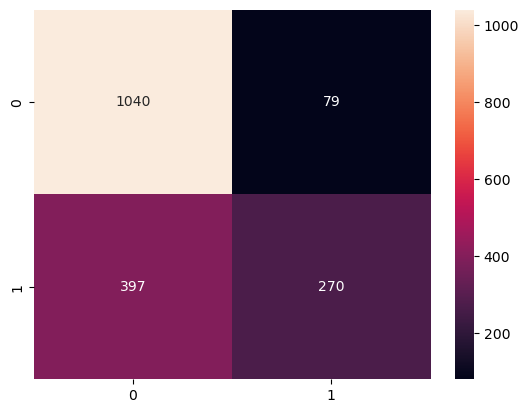

In [277]:
sns.heatmap(confusion_matrix(y_train,y_train_pred),annot =True , fmt='.4g')

In [281]:
accuracy_score(y_train , y_train_pred)*100

73.34826427771557

In [283]:
print(classification_report(y_train , y_train_pred))

              precision    recall  f1-score   support

           0       0.72      0.93      0.81      1119
           1       0.77      0.40      0.53       667

    accuracy                           0.73      1786
   macro avg       0.75      0.67      0.67      1786
weighted avg       0.74      0.73      0.71      1786



## test data

In [291]:
confusion_matrix(y_test_pred , y_test)

array([[466, 247],
       [ 86,  81]])

<Axes: >

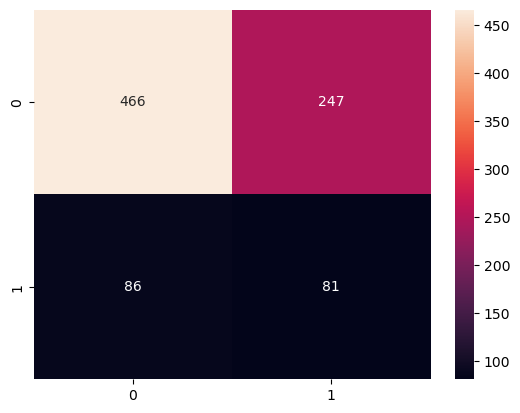

In [293]:
sns.heatmap(confusion_matrix(y_test_pred , y_test),annot=True ,fmt ='.3g')

In [296]:
accuracy_score(y_test_pred , y_test)*100

62.15909090909091

In [298]:
print(classification_report(y_test_pred , y_test))

              precision    recall  f1-score   support

           0       0.84      0.65      0.74       713
           1       0.25      0.49      0.33       167

    accuracy                           0.62       880
   macro avg       0.55      0.57      0.53       880
weighted avg       0.73      0.62      0.66       880



 # sample data

In [381]:
x[:1]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.99097,2.963135


In [395]:
x.ndim  # 2D data

2

In [421]:
new_data = [[7.080795,	2.890455,	27437236.318981	,7.300212,	368.516441,	564.308654,	2210.379783	,8336.99097,	2.963135]]

In [422]:
new_data_sc = sc.transform(new_data)
dtree.predict(new_data_sc)

array([0])